# 246. Seeds that allow mismatches, tested on CED-9/BCL2 and P66/CD47

Notebook 245 ([PR 54](https://github.com/seanome/2024-kmerseek-analysis/pull/54)) found
that an exact H/P seed stands out from chance in a human-proteome search only at k ≥ 34,
where 0.6% or fewer of Pfam pairs at 20-30% identity share one. It ended: the fix has to
be a seed that allows mismatches, more letters, or a smaller database. This notebook tests
the first option.

**Question.** Is there a seed that allows mismatches, in a two-letter H/P alphabet, that
finds remote homologs and still stands out from chance? Does keeping half the seeds
(scaled 2) cut the index without losing them?

A seed is the rule that picks which query-target diagonals a search looks at further. A
diagonal is one fixed offset between the two sequences, with no gaps. Four kinds are
tested, each at several sizes, in hp_thomas_dill2 and hp_lehninger2:

| kind | the seed fires when | example |
|---|---|---|
| exact | k positions in a row are in the same class (kmerseek today) | `exact k=20` |
| spaced | the positions under the 1s of a pattern are in the same class; positions under 0s may differ (Ma, Tromp and Li 2002) | `spaced 110110110…` |
| chained | n exact k-mers lie on the same diagonal, not overlapping, all inside W positions; the gaps between them may differ (BLAST's two-hit rule, Altschul et al. 1997, with n hits) | `chained 3 x k=8 in 60` |
| window | at least m of the last L positions on the diagonal are in the same class, anywhere | `window 36 of 40` |

Chained seeds are the "several k = 12 next to each other" or "k = 5 at consecutive
positions" idea. A window seed is the most permissive rule with the same number of
required matches. It cannot be looked up in an index directly, but a window of L with at
most j mismatches always holds an exact run of L/(j + 1) or more, so it can be found by
indexing that exact run and checking the window around it.

Scaled 2 keeps the half of the seed keys whose hash is even, the rule kmerseek's
`--scaled` uses. The key is the classes under the seed's 1s, which are the same in query
and target where the seed fires, so both sides keep or drop the same seeds.

**Data.**

| what | where |
|---|---|
| queries | CED-9 (*C. elegans*, 280 aa) and mature P66 (*Borreliella burgdorferi*, 597 aa), the sequences notebook 241 searched (`tables/246_queries_from_241.fasta`) |
| target database | GENCODE v49 canonical human proteins, 19,732 proteins, 11.35 M residues; contains BCL2 (ENSP00000329623) and CD47 (ENSP00000355361) |
| homolog pairs | Pfam seed-alignment pairs of notebook 230 with at least 50 aligned positions, read by identity bin; 37,086 pairs at 20-30% identity |
| tool | a seed scan written for this notebook (`notebooks/mismatch_seed_utils.py`, numba), **not kmerseek**. It walks every diagonal of the query against every human protein. Tested against a plain-Python reading of each rule in `scripts/tests/test_mismatch_seed_utils.py` |
| run | `pixi exec --spec numba --spec numpy --spec polars -- python scripts/run_246_mismatch_seeds.py`, about 2 minutes on 16 cores, 2026-10-06 |

**Measures.** For each seed and alphabet:

* *reach*: the share of Pfam 20-30% pairs whose own alignment diagonal has at least one
  seed. Higher is better.
* *chance seeds per search*: seed positions on the 19,731 human proteins that are not the
  partner, with CED-9 as the query. Nearly all of these are chance. Lower is better;
  notebook 245 put the need at about 1 (or 10) per search.
* *partner rank*: each human protein is scored by the most seed positions on any one of
  its diagonals, and the partner (BCL2 for CED-9, CD47 for P66) is ranked among all 19,732.
  1 is best. Ties share the best rank of the tie, and the number tied is shown.

**Decision rule.** Build a mismatch-tolerant seed into kmerseek if either (1) some seed
puts BCL2 or CD47 in the top 10 of the human proteome and a random human protein does as
well in under 5% of draws, or (2) some seed with at most 10 chance seeds per search reaches
at least 10% of Pfam 20-30% pairs. Otherwise conclude that the shape of an H/P seed does
not rescue it. Keep scaled 2 if it halves the index while staying on the same
reach-for-chance curve. This rule was written after the first run of the scan, so it is
not a blind test; both thresholds were taken from notebook 245, not from these results.

In [1]:
import sys
from pathlib import Path

import polars as pl

sys.path.insert(0, str(Path.cwd()))
import pubfig as pf
import mismatch_seed_figures as mf

pf.use_style()
pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_fmt_str_lengths(45)
pl.Config.set_tbl_hide_column_data_types(True)
s = mf.search()
print(mf.schemes().select("scheme", "family", "scaled", "weight", "span"))

shape: (59, 5)
┌────────────────────────────────────────────────┬─────────┬────────┬────────┬──────┐
│ scheme                                         ┆ family  ┆ scaled ┆ weight ┆ span │
╞════════════════════════════════════════════════╪═════════╪════════╪════════╪══════╡
│ exact k=8                                      ┆ exact   ┆ 1      ┆ 8      ┆ 8    │
│ exact k=8, scaled 2                            ┆ exact   ┆ 2      ┆ 8      ┆ 8    │
│ exact k=10                                     ┆ exact   ┆ 1      ┆ 10     ┆ 10   │
│ exact k=10, scaled 2                           ┆ exact   ┆ 2      ┆ 10     ┆ 10   │
│ exact k=12                                     ┆ exact   ┆ 1      ┆ 12     ┆ 12   │
│ exact k=12, scaled 2                           ┆ exact   ┆ 2      ┆ 12     ┆ 12   │
│ exact k=14                                     ┆ exact   ┆ 1      ┆ 14     ┆ 14   │
│ exact k=14, scaled 2                           ┆ exact   ┆ 2      ┆ 14     ┆ 14   │
│ exact k=16                           

## 1. Where each seed fires on the BH1 block of CED-9 and BCL2

BH1 is the region notebook 245 follows: BCL2 130-166 against CED-9 154-190, one gapless
diagonal, 5 of 37 residues identical. Below are the residues, their H/P classes, and the
positions on that diagonal where each seed fires (a dot is the last position of a seed).
The number after each seed is how often the same seed fires on the other human proteins.

How to read it: a seed that fires here can start a search from BH1. A seed with millions
of chance positions starts one from almost everywhere else too.

hp_thomas_dill2 (H = ACFILMVWY, P = the rest); BH1 is CED-9 154-190 / BCL2 130-166
CED-9     140 AVPRISFSLYQDVVRTVGNAQTDQCPMSYGRLIGLISFGGFVAAKMMESVELQGQVRNLFV 200
                                           ||      |||                        identical residues
BCL2      116 SSQLHLTPFTARGRFATVVEELFRDGVNWGRIVAFFEFGGVMCVESVNREMSPLVDNIALW 176
CED-9 HP  140 HHPPHPHPHHPPHHPPHPPHPPPPHPHPHPPHHPHHPHPPHHHHPHHPPHPHPPPHPPHHH
                |    ||  |        |  | |||||||| ||||||||||| |||   |   | |||   same class: 33 of 61
BCL2 HP   116 PPPHPHPPHPHPPPHHPHHPPHHPPPHPHPPHHHHHPHPPHHHHPPHPPPHPPHHPPHHHH

hp_lehninger2 (H = AFGILMPVWY, P = the rest); BH1 is CED-9 154-190 / BCL2 130-166
CED-9     140 AVPRISFSLYQDVVRTVGNAQTDQCPMSYGRLIGLISFGGFVAAKMMESVELQGQVRNLFV 200
                                           ||      |||                        identical residues
BCL2      116 SSQLHLTPFTARGRFATVVEELFRDGVNWGRIVAFFEFGGVMCVESVNREMSPLVDNIALW 176
CED-9 HP  140 HHHPHPHPHHPPHHPPHHPHPPPPPHHPHHPHHHHHPHHHHHHHPHHPPHPHPHP

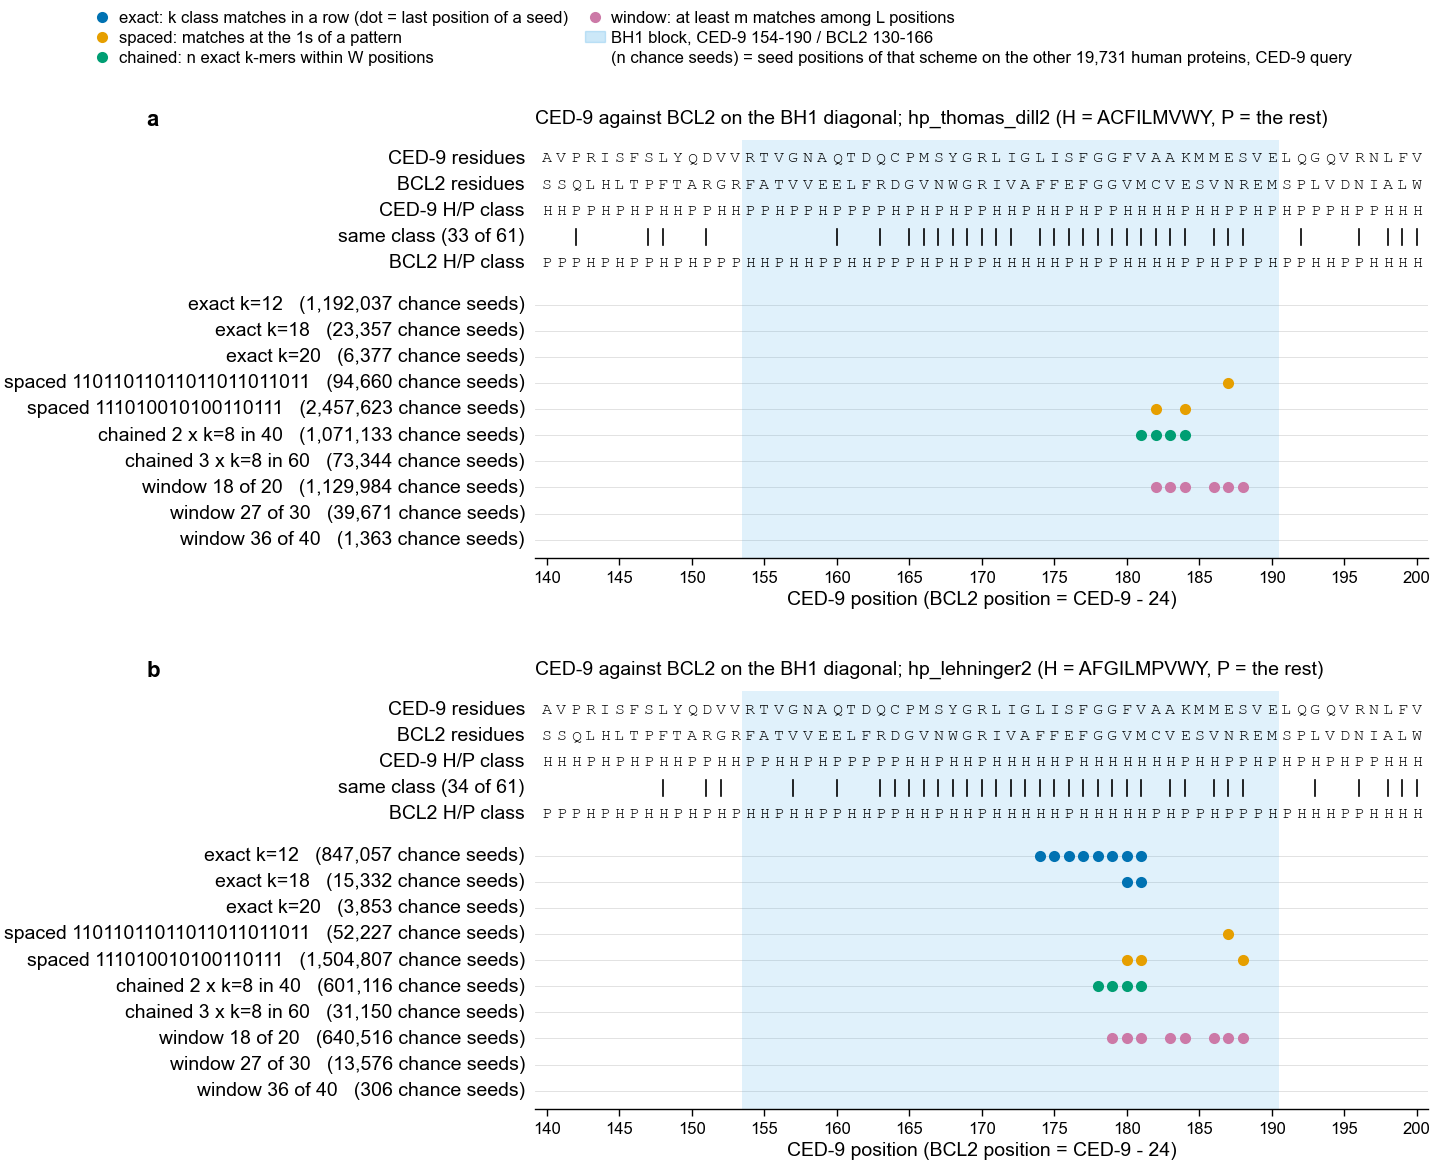

In [2]:
for alphabet in mf.ALPHABETS:
    mf.print_bh1(alphabet)
    print()
pos = mf.read("246_bh1_diagonal_seed_positions.tsv")
bh1 = (
    pos.filter(pl.col("ced9_position").is_between(154, 190))
    .group_by("alphabet", "scheme")
    .agg(
        pl.len().alias("seed_positions_in_BH1"),
        pl.col("ced9_position").min().alias("first_ced9_end"),
        pl.col("ced9_position").max().alias("last_ced9_end"),
    )
    .join(
        s.filter(pl.col("query") == "CED-9").select(
            "alphabet", "scheme", "chance_seed_positions_per_search"
        ),
        on=["alphabet", "scheme"],
    )
    .sort("alphabet", "chance_seed_positions_per_search")
)
print(bh1)
mf.fig_bh1(pos, s, mf.FIG / "246_bh1_diagonal_seeds_ced9_bcl2")

In hp_thomas_dill2 the longest class-identical run in BH1 is 11, so no exact seed of 12
or more fires there. Seeds that allow mismatches do: the spaced pattern 11011… of weight
16, two exact 8-mers within 40, and 18 of 20 matches all fire at CED-9 181-188. In
hp_lehninger2 the run is 19, so exact k = 18 fires as well. Each of these fires tens of
thousands to millions of times on the rest of the proteome. The strictest seeds drawn
(exact k = 20, chained 3 x k=8 in 60, window 27 of 30, window 36 of 40), with 306 to 73,344
chance positions, do not fire on BH1 in either alphabet.

## 2. Reach against chance: do mismatches buy anything?

One point per seed. x: chance seeds per search (CED-9 query, other 19,731 human
proteins). y: share of Pfam pairs at 20-30% identity whose alignment holds a seed. The
blue line joins the exact seeds, k = 8 to 32. The step from 1 to 10 on x takes as much room
as the step from 1,000 to 10,000. A seed above the blue line finds more homologs than an
exact seed with the same number of chance hits. The vermillion lines are what a
proteome search needs (notebook 245). A useful seed would sit in the top left.

Best reach on Pfam 20-30% pairs per kind of seed, among seeds with at most this many chance seeds per search
shape: (24, 6)
┌─────────────────┬──────────────────────┬─────────┬────────────────────────────────────────────────┬──────────────────────────────────┬─────────────────────────────┐
│ alphabet        ┆ at_most_chance_seeds ┆ family  ┆ scheme                                         ┆ chance_seed_positions_per_search ┆ fraction_of_pairs_with_seed │
╞═════════════════╪══════════════════════╪═════════╪════════════════════════════════════════════════╪══════════════════════════════════╪═════════════════════════════╡
│ hp_lehninger2   ┆ 10                   ┆ window  ┆ window 54 of 60                                ┆ 1                                ┆ 0.006202                    │
│ hp_lehninger2   ┆ 10                   ┆ exact   ┆ exact k=28, scaled 2                           ┆ 4                                ┆ 0.004422                    │
│ hp_lehninger2   ┆ 100                  

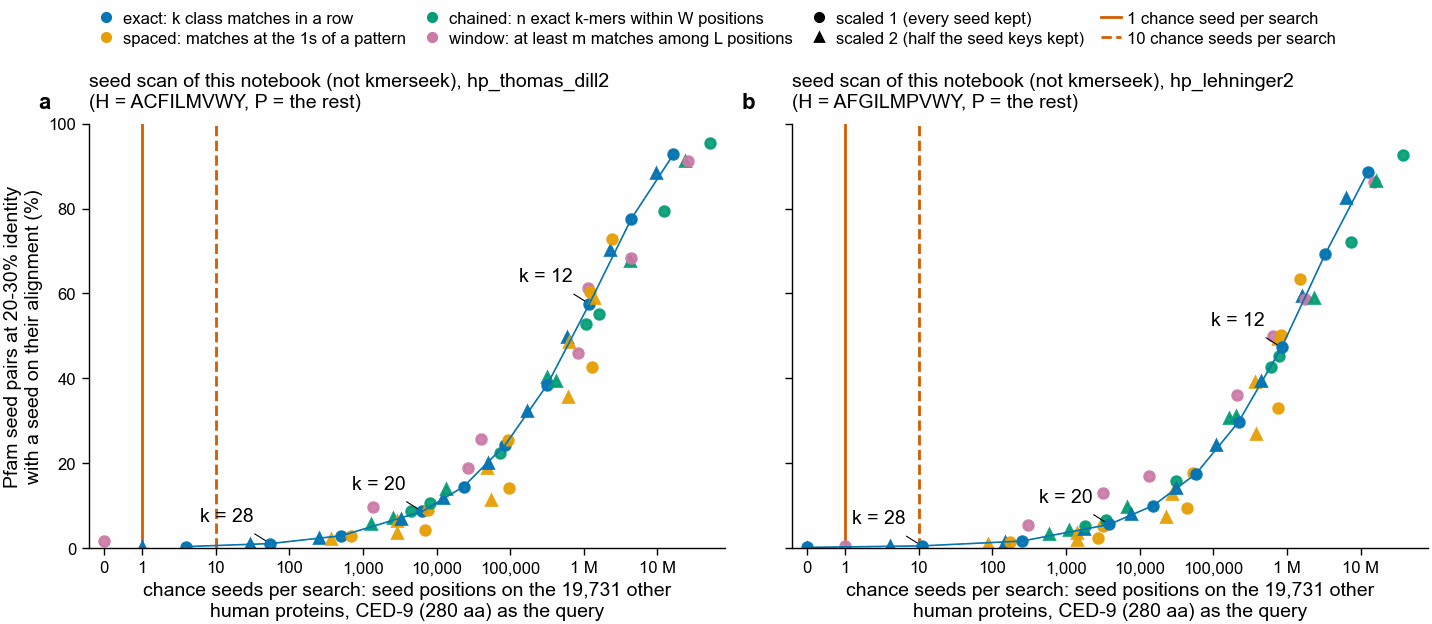

In [3]:
t = mf.frontier_table()
rows = []
for cap in (10, 100, 1_000, 10_000):
    best = (
        t.filter(pl.col("chance_seed_positions_per_search") <= cap)
        .sort("fraction_of_pairs_with_seed", descending=True)
        .group_by("alphabet", "family", maintain_order=True)
        .first()
        .with_columns(pl.lit(cap).alias("at_most_chance_seeds"))
    )
    rows.append(best)
best = (
    pl.concat(rows)
    .select(
        "alphabet",
        "at_most_chance_seeds",
        "family",
        "scheme",
        "chance_seed_positions_per_search",
        "fraction_of_pairs_with_seed",
    )
    .sort(
        "alphabet",
        "at_most_chance_seeds",
        "fraction_of_pairs_with_seed",
        descending=[False, False, True],
    )
)
print(
    "Best reach on Pfam 20-30% pairs per kind of seed, among seeds with at most this many chance seeds per search"
)
print(best)
mf.fig_frontier(t, mf.FIG / "246_seed_reach_vs_chance_pfam_human")

All four kinds of seed lie close to one curve. Allowing mismatches moves a seed along the
curve more than above it. The window seeds sit highest, as expected: counting matches
anywhere in a window is the most sensitive test for a given number of required matches.
At a few hundred chance seeds per search a window seed reaches about 3 times the pairs an
exact seed reaches (hp_lehninger2: window 36 of 40, 306 chance seeds, 5.4%, against exact
k = 24, 252 chance seeds, 1.7%).

At the level a proteome search needs, nothing gets far. With at most 10 chance seeds per
search the best seed reaches 1.6% of the pairs (hp_thomas_dill2, window 54 of 60), against
0.4% for the best exact seed (k = 32). The 10% in the decision rule is first reached at 3,158
chance seeds per search (hp_lehninger2, window 48 of 60, 13%).

## 3. Where BCL2 and CD47 rank

Each human protein is scored by the most seed positions on one of its diagonals, and the
partner is ranked among all 19,732. One panel per query and alphabet. The yellow band is the
top 10. Grey crosses at the bottom are seeds that never fire on the partner. The dash-dot
line is the partner's rank with no seed at all: the best ungapped segment over every
diagonal, +1 per class match and -2 per mismatch (the scoring of notebook 232).

shape: (16, 7)
┌───────┬─────────────────┬─────────┬─────────┬───────────────────────────┬───────────────────┬────────────────────────────────────────────────┐
│ query ┆ alphabet        ┆ family  ┆ n_seeds ┆ n_seeds_firing_on_partner ┆ best_partner_rank ┆ seed_with_best_rank                            │
╞═══════╪═════════════════╪═════════╪═════════╪═══════════════════════════╪═══════════════════╪════════════════════════════════════════════════╡
│ CED-9 ┆ hp_lehninger2   ┆ chained ┆ 14      ┆ 9                         ┆ 4428              ┆ chained 4 x k=5 in 40, scaled 2                │
│ CED-9 ┆ hp_lehninger2   ┆ exact   ┆ 20      ┆ 12                        ┆ 817               ┆ exact k=16, scaled 2                           │
│ CED-9 ┆ hp_lehninger2   ┆ spaced  ┆ 16      ┆ 8                         ┆ 551               ┆ spaced 11011011011011011011011, scaled 2       │
│ CED-9 ┆ hp_lehninger2   ┆ window  ┆ 8       ┆ 3                         ┆ 4243              ┆ window 18 of 20    

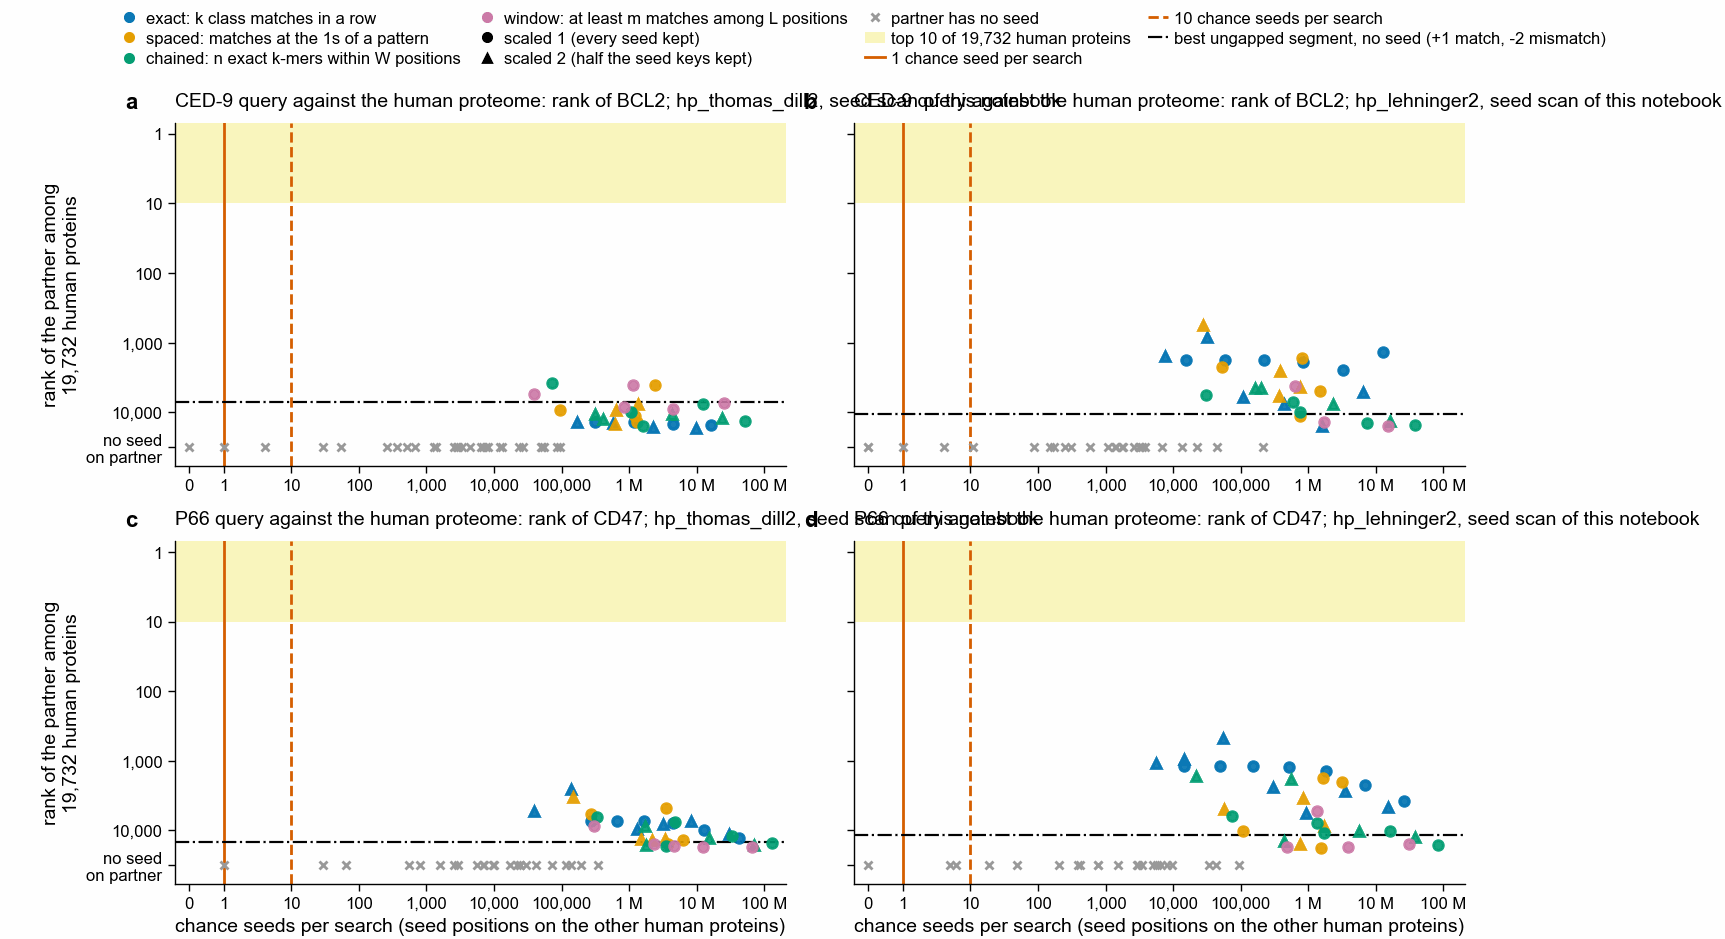

In [4]:
rank_table = (
    s.filter(pl.col("family") != "extend")
    .group_by("query", "alphabet", "family")
    .agg(
        pl.len().alias("n_seeds"),
        pl.col("partner_rank").is_not_null().sum().alias("n_seeds_firing_on_partner"),
        pl.col("partner_rank").min().alias("best_partner_rank"),
        pl.col("scheme")
        .filter(pl.col("partner_rank").is_not_null())
        .sort_by(pl.col("partner_rank").filter(pl.col("partner_rank").is_not_null()))
        .first()
        .alias("seed_with_best_rank"),
    )
    .sort("query", "alphabet", "family")
)
print(rank_table)
print(
    "\nBest rank per query and alphabet, with the number of proteins tied at that score"
)
print(
    s.filter(pl.col("partner_rank").is_not_null())
    .sort("partner_rank")
    .group_by("query", "alphabet", maintain_order=True)
    .first()
    .select(
        "query",
        "partner",
        "alphabet",
        "scheme",
        "partner_score",
        "partner_rank",
        "partner_n_tied",
        "n_proteins_with_seed",
        "chance_seed_positions_per_search",
    )
)
print("\nNo seed: best ungapped segment, +1 / -2")
print(
    s.filter(pl.col("family") == "extend").select(
        "query",
        "partner",
        "alphabet",
        "partner_score",
        "partner_rank",
        "partner_n_tied",
    )
)
mf.fig_partner_rank(s, mf.FIG / "246_partner_rank_bcl2_cd47_human")

No seed of any kind puts BCL2 or CD47 near the top 10. The best rank of BCL2 is 551
(hp_lehninger2, spaced seed of weight 16 at scaled 2, with 2,517 other proteins tied at
the same score), and of CD47 472 (hp_lehninger2, exact k = 16 at scaled 2). In
hp_thomas_dill2 the best ranks are 3,788 and 2,578. The seeds strict enough to come near
the vermillion lines never fire on the partner at all. With no seed, the best ungapped
H/P segment ranks BCL2 7,127 of 19,732 and CD47 14,640: thousands of human proteins
hold a longer stretch of class agreement with CED-9 than BCL2 does.

The proteins that do rank first are listed in `tables/246_human_proteome_top_targets.tsv`.

In [5]:
top = mf.read("246_human_proteome_top_targets.tsv")
print(
    top.filter(
        pl.col("scheme").is_in(
            ["exact k=20", "window 36 of 40", "chained 2 x k=12 in 60"]
        )
        & (pl.col("rank") <= 5)
    ).select("query", "alphabet", "scheme", "rank", "gene", "length", "score")
)

shape: (80, 7)
┌───────┬─────────────────┬────────────────────────┬──────┬─────────────────┬────────┬───────┐
│ query ┆ alphabet        ┆ scheme                 ┆ rank ┆ gene            ┆ length ┆ score │
╞═══════╪═════════════════╪════════════════════════╪══════╪═════════════════╪════════╪═══════╡
│ CED-9 ┆ hp_thomas_dill2 ┆ exact k=20             ┆ 1    ┆ DOCK7           ┆ 2140   ┆ 14.0  │
│ CED-9 ┆ hp_thomas_dill2 ┆ exact k=20             ┆ 1    ┆ MYH16           ┆ 1114   ┆ 14.0  │
│ CED-9 ┆ hp_thomas_dill2 ┆ exact k=20             ┆ 3    ┆ FNTA            ┆ 379    ┆ 12.0  │
│ CED-9 ┆ hp_thomas_dill2 ┆ exact k=20             ┆ 3    ┆ CCDC88B         ┆ 1476   ┆ 12.0  │
│ CED-9 ┆ hp_thomas_dill2 ┆ exact k=20             ┆ 3    ┆ MECP2           ┆ 498    ┆ 12.0  │
│ CED-9 ┆ hp_thomas_dill2 ┆ chained 2 x k=12 in 60 ┆ 1    ┆ ENSG00000283782 ┆ 1213   ┆ 13.0  │
│ CED-9 ┆ hp_thomas_dill2 ┆ chained 2 x k=12 in 60 ┆ 1    ┆ RAD50           ┆ 1312   ┆ 13.0  │
│ CED-9 ┆ hp_thomas_dill2 ┆ chained

## 4. Is the best rank better than luck?

Section 3 takes the best of 59 ranks per alphabet. The best of many ranks is small even for
a protein that has nothing to do with the query. So the same is done for a human protein
drawn at random: its best rank over the same 59 seeds, 20,000 draws. If the partner's best
rank is not better than most random proteins' best ranks, the seeds have not found it.

shape: (4, 8)
┌───────┬─────────┬─────────────────┬───────────┬──────────────────────────────┬─────────────────────────────────┬───────────────────────────────────┬─────────┐
│ query ┆ partner ┆ alphabet        ┆ n_schemes ┆ partner_best_rank_any_scheme ┆ random_protein_median_best_rank ┆ p_random_protein_at_least_as_good ┆ n_draws │
╞═══════╪═════════╪═════════════════╪═══════════╪══════════════════════════════╪═════════════════════════════════╪═══════════════════════════════════╪═════════╡
│ CED-9 ┆ BCL2    ┆ hp_thomas_dill2 ┆ 59        ┆ 3788.0                       ┆ 772.0                           ┆ 0.8522                            ┆ 20000   │
│ CED-9 ┆ BCL2    ┆ hp_lehninger2   ┆ 59        ┆ 551.0                        ┆ 587.0                           ┆ 0.48985                           ┆ 20000   │
│ P66   ┆ CD47    ┆ hp_thomas_dill2 ┆ 59        ┆ 2578.0                       ┆ 1264.0                          ┆ 0.69495                           ┆ 20000   │
│ P66   ┆ CD47    ┆ 

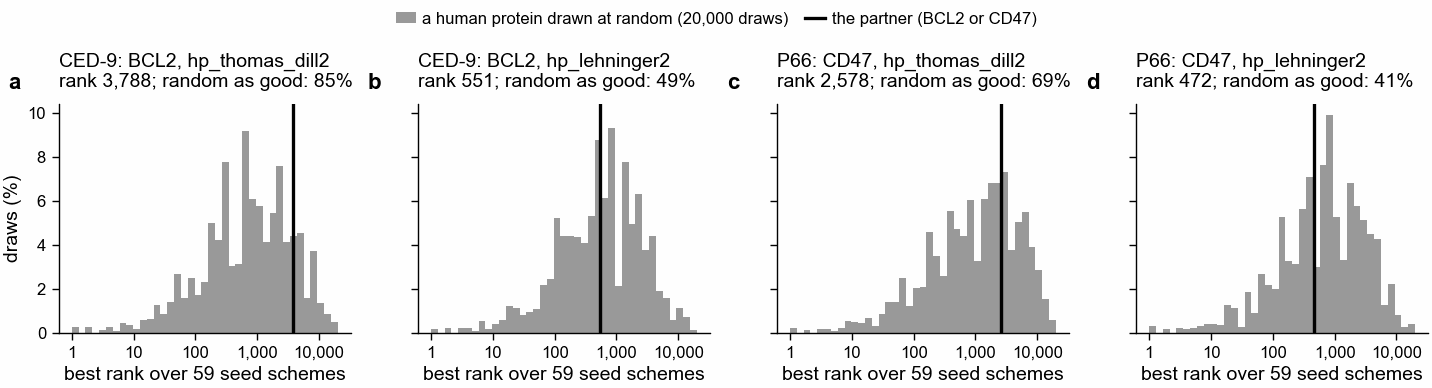

In [6]:
null = mf.read("246_random_protein_null.tsv")
draws = mf.read("246_random_protein_best_rank_draws.tsv")
print(null)
mf.fig_random_null(draws, null, mf.FIG / "246_random_protein_null_human")

A random human protein does as well as or better than the partner in 41% to 85% of draws.
The partners are not separated from chance by any of the 59 seeds, as notebook 241 found
for exact seeds across 19 alphabets (BCL2: 97%, CD47: 90%).

## 5. Scaled 2: half the index, how much reach?

Each keyed seed (exact, spaced, chained) at scaled 1 against the same seed shape at scaled
2. (a) Entries in an index of the human proteome: one per database position whose seed key
is kept. (b) Reach on Pfam 20-30% pairs. Window seeds have no key and are not shown.

shape: (6, 7)
┌─────────────────┬─────────┬──────────┬───────────────────────────────────┬─────────────────┬─────────────────┬───────────────────────────────────┐
│ alphabet        ┆ family  ┆ n_shapes ┆ median_index_scaled2_over_scaled1 ┆ min_index_ratio ┆ max_index_ratio ┆ median_reach_scaled2_over_scaled1 │
╞═════════════════╪═════════╪══════════╪═══════════════════════════════════╪═════════════════╪═════════════════╪═══════════════════════════════════╡
│ hp_lehninger2   ┆ chained ┆ 7        ┆ 0.50747                           ┆ 0.490173        ┆ 0.565523        ┆ 0.677492                          │
│ hp_lehninger2   ┆ exact   ┆ 10       ┆ 0.499775                          ┆ 0.494542        ┆ 0.536456        ┆ 0.813354                          │
│ hp_lehninger2   ┆ spaced  ┆ 8        ┆ 0.50091                           ┆ 0.499736        ┆ 0.503808        ┆ 0.77466                           │
│ hp_thomas_dill2 ┆ chained ┆ 7        ┆ 0.511028                          ┆ 0.484205       

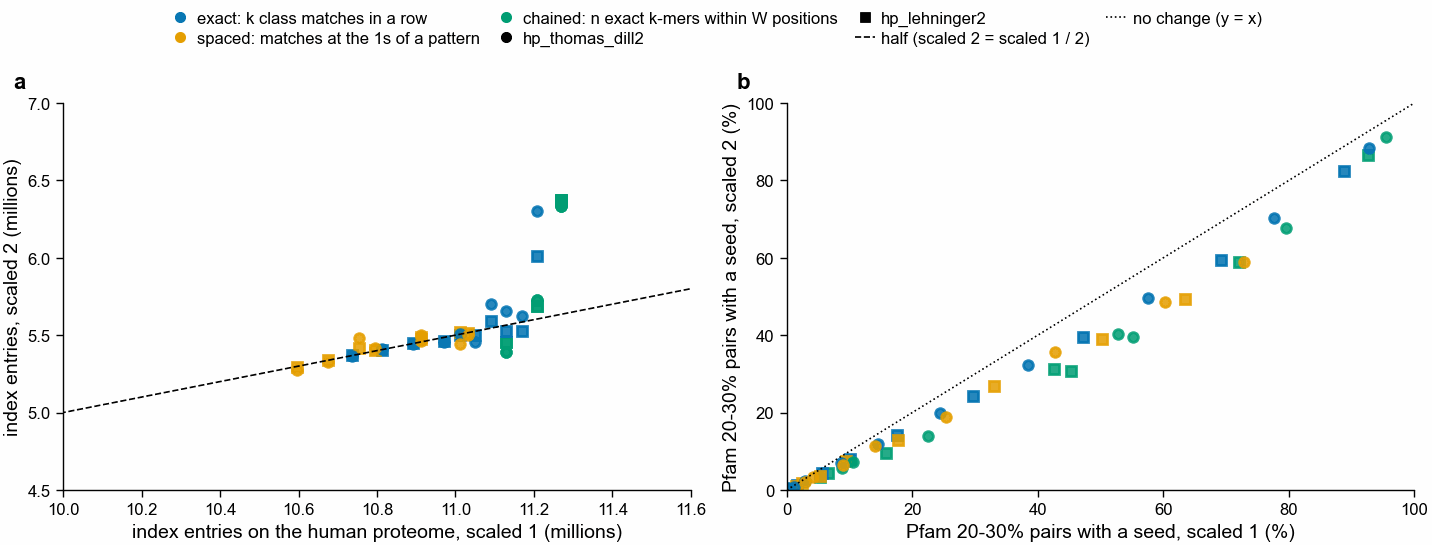

In [7]:
sp = mf.scaled_pairs()
print(
    sp.group_by("alphabet", "family")
    .agg(
        pl.len().alias("n_shapes"),
        pl.col("index_ratio").median().alias("median_index_scaled2_over_scaled1"),
        pl.col("index_ratio").min().alias("min_index_ratio"),
        pl.col("index_ratio").max().alias("max_index_ratio"),
        pl.col("reach_ratio").median().alias("median_reach_scaled2_over_scaled1"),
    )
    .sort("alphabet", "family")
)
print(
    sp.select(
        "alphabet",
        "shape",
        "index_entries",
        "index_entries_scaled2",
        "fraction_of_pairs_with_seed",
        "fraction_of_pairs_with_seed_scaled2",
        "chance_seed_positions_per_search",
        "chance_seed_positions_per_search_scaled2",
    )
)
mf.fig_scaled(sp, mf.FIG / "246_scaled2_index_and_reach_pfam_human")

Scaled 2 halves the index: the median ratio is 0.50, from 0.48 to 0.57. It is above 0.5
for short seeds (k = 5 and 8, and the PatternHunter weight-11 seed), because a two-letter
alphabet has only 32 or 256 keys at those lengths and the kept half of the keys does not
cover exactly half the positions. Reach falls to between 0.68 and 0.82 of its scaled-1
value (median per alphabet and kind of seed), because a homolog pair usually has more than one seed
position and losing some of them does not lose the pair. In Section 2 the scaled-2 points
(triangles) sit on the same curve as the scaled-1 points (circles): halving the seeds
trades reach for chance hits at the same rate as making k a little longer. It saves half
the memory and costs nothing in sensitivity at a given number of chance hits, but it does
not move the curve.

## 6. Summary and conclusions

**Claim.** In a two-letter H/P alphabet, no seed shape found here (exact, spaced, chained
or window, 59 seeds in all, at scaled 1 or 2) finds BCL2 from CED-9 or CD47 from P66 in a
search of the human proteome, and none reaches more than 1.6% of Pfam 20-30% pairs while
firing by chance 10 times or fewer per search.

1. Seeds that allow mismatches do find the BH1 block where exact seeds cannot. In
   hp_thomas_dill2 no exact seed of k ≥ 12 fires on BH1, but a spaced seed of weight 16,
   two 8-mers within 40 positions, and 18 of 20 matches all do. Each of them also fires
   between 94,660 and 2.5 million times on the rest of the human proteome.
2. All seed shapes lie near one curve of reach against chance hits. Window seeds sit
   highest, about 3 times the reach of an exact seed at a few hundred chance seeds per search.
   At 10 or fewer chance seeds per search, the best seed reaches 1.6% of Pfam 20-30% pairs.
3. The partners are not found. Best rank over all 59 seeds: BCL2 551, CD47 472 of 19,732
   (hp_lehninger2), with hundreds to thousands of proteins tied at the same score. A random
   human protein does as well in 41% to 85% of draws.
4. Scaled 2 halves the index (median 0.50 of the entries) and keeps 68-82% of the reach. It
   stays on the same curve, so it is a free memory saving at a given chance-hit level, not a
   gain in sensitivity.

**Decision.** Neither condition of the rule is met: the best partner rank is 472, not 10,
and the best reach at ≤ 10 chance seeds per search is 1.6%, not 10%. A mismatch-tolerant
H/P seed is not worth building into kmerseek for this purpose. The reason is the one
notebook 245 gives: two letters carry too little information per position for any rule
that looks at 60 positions or fewer. Seed shape changes which homologs a seed catches,
not how much information each position carries. Of the three ways out that notebook 245
named, this rules out the first for H/P; the remaining two are more letters per position
or a smaller database. Scaled 2 is worth keeping on its own merits, as a way to halve
index memory at no cost in the reach-for-chance trade-off.

**What this does not show.** The scan scores a protein by its single best diagonal and
does no extension or E-value; kmerseek's own scoring could rank differently, though the
no-seed segment score (Section 3) suggests the information is not there to rank on. Only
two-letter alphabets were tested. Chance seeds were counted with CED-9 as the query; P66 is
twice as long and draws about twice as many.